In [1]:
import sys
import os

os.chdir('/path/to/concept_inversion/Experiments/')
sys.path.append(os.path.abspath(".."))
import pandas as pd

from utils import general_utils
from utils.general_utils import plot_random_image_samples

In [21]:
DATASET_NAME = 'GoEmotions'

# Print Qualitative Info About Datasets

In [22]:
metadata = pd.read_csv(f'../Data/{DATASET_NAME}/metadata.csv')
print(f"Number of data samples: {len(metadata)}")
concept_cols = [col for col in metadata.columns if col not in ['image_path', 'class', 'split']]                                               
print(f"Number of distinct concepts: {len(concept_cols)}")
concept_categories = set([col.split("::")[0] for col in concept_cols])
print(f"Number of distinct concept categories: {len(concept_categories)}")

Number of data samples: 820
Number of distinct concepts: 29
Number of distinct concept categories: 29


# Show Statistics of Positive/Negative Concepts

In [ ]:
#By Sample

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv(f'../Data/{DATASET_NAME}/metadata.csv')  # Replace with your file path

# Exclude non-concept columns
excluded_columns = {"image_path", "class", "split", "text_path", "text_path.1"}
concept_columns = [col for col in df.columns if col not in excluded_columns]
print(concept_columns)

# Split data into train and test sets
train_df = df[df["split"] == "train"]
test_df = df[df["split"] == "test"]

# Count occurrences of each concept
train_counts = train_df[concept_columns].sum()
test_counts = test_df[concept_columns].sum()

# Total counts across train and test
total_counts = train_counts + test_counts

# Sort concepts by total frequency (ascending)
sorted_concepts = total_counts.sort_values().index.tolist()

# Split the sorted concepts in half
mid = len(sorted_concepts) // 2
low_freq_concepts = sorted_concepts[:mid]
high_freq_concepts = sorted_concepts[mid:]

# Print or use the concept splits
print(f"Low freq concepts: {low_freq_concepts}")
print(f"High freq concepts: {high_freq_concepts}")     

['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise']
Low freq concepts: ['pride', 'relief', 'nervousness', 'grief', 'embarrassment', 'remorse', 'excitement', 'fear', 'disappointment', 'disgust', 'desire', 'surprise', 'realization']
High freq concepts: ['confusion', 'joy', 'sadness', 'anger', 'love', 'caring', 'optimism', 'amusement', 'curiosity', 'disapproval', 'approval', 'annoyance', 'gratitude', 'admiration']


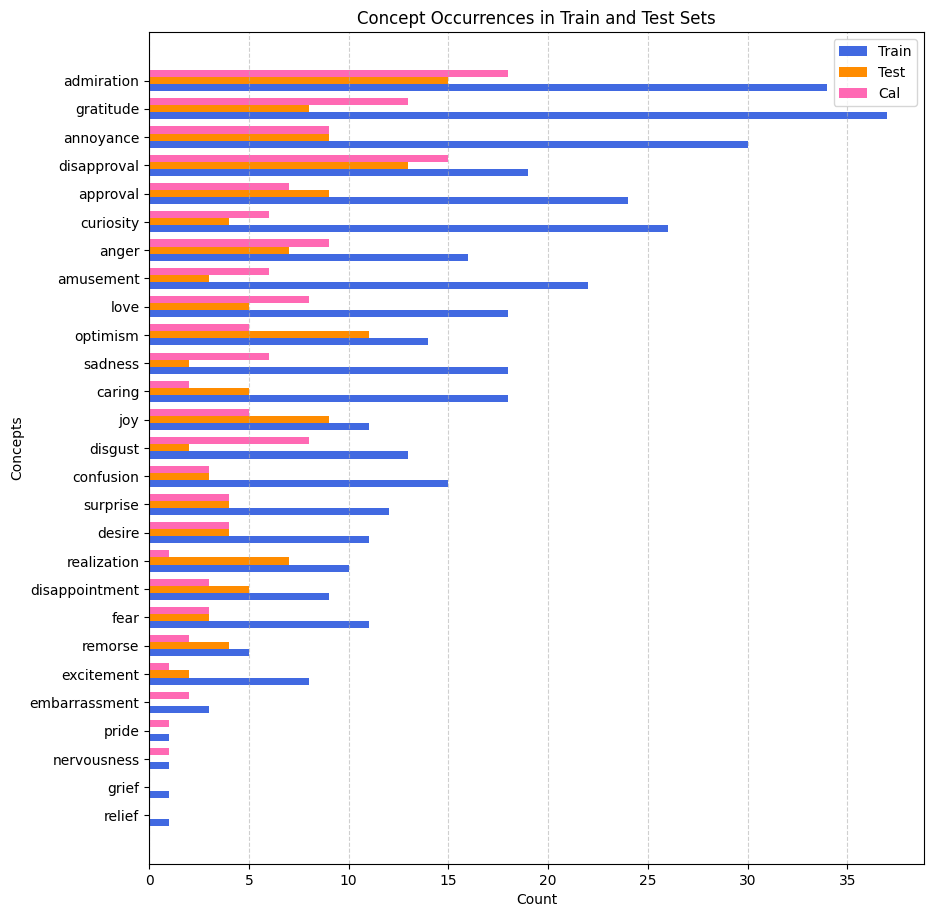

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
df = pd.read_csv(f'../Data/{DATASET_NAME}/metadata.csv')  # Replace with your file path

# Exclude non-concept columns
excluded_columns = {"image_path", "class", "split", "text_path", "text_path.1"}
concept_columns = [col for col in df.columns if col not in excluded_columns]

# Split data into train and test sets
train_df = df[df["split"] == "train"]
test_df = df[df["split"] == "test"]
cal_df = df[df["split"] == "cal"]

# Count occurrences of each concept
train_counts = train_df[concept_columns].sum()
test_counts = test_df[concept_columns].sum()
cal_counts = cal_df[concept_columns].sum()

# Sort concepts by total occurrences (train + test) for better visualization
sorted_indices = (train_counts + test_counts + cal_counts).sort_values().index
train_counts = train_counts[sorted_indices]
test_counts = test_counts[sorted_indices]
cal_counts = cal_counts[sorted_indices]

# Set up bar positions
y_pos = np.arange(len(concept_columns))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(10, len(concept_columns) * 0.4))

# Plot bars
ax.barh(y_pos - bar_width, train_counts, height=bar_width, label="Train", color="royalblue")
ax.barh(y_pos, test_counts, height=bar_width, label="Test", color="darkorange")
ax.barh(y_pos + bar_width, cal_counts, height=bar_width, label="Cal", color="hotpink")

# Labels and title
plt.xlabel("Count")
plt.ylabel("Concepts")
plt.title("Concept Occurrences in Train and Test Sets")
plt.yticks(y_pos, sorted_indices)
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.6)

# Show plot
plt.show()


In [ ]:
#By Patch

# Example of Samples from a Dataset

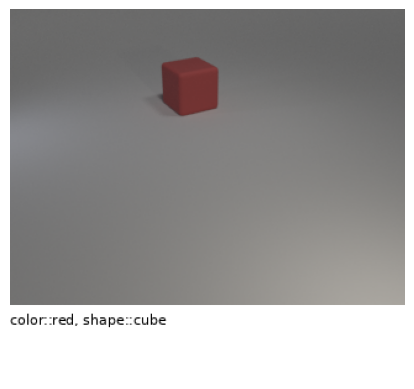

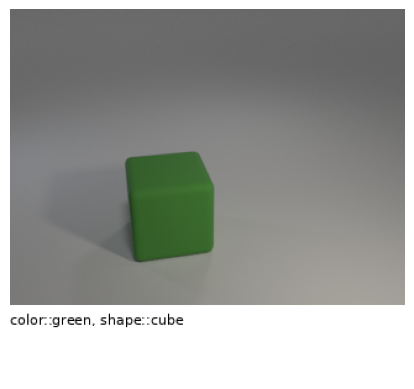

In [3]:
plot_random_image_samples(num_samples=2)